## Descriptive Analysis

In [2]:
# Load processed data
%matplotlib inline              # %matplotlib widget

import pandas as pd
import matplotlib.pyplot as plt

INPUT_PATH = "../data/processed/dataset_processed.csv"

df2 = pd.read_csv(INPUT_PATH)
df2["date"] = pd.to_datetime(df2["date"])

print(df2.head())
print(df2.info())

        date  tavg  tmin  tmax  year  month  day  day_of_year  season  \
0 1907-10-01  13.5   7.9  20.7  1907     10    1          274  Autumn   
1 1907-10-02  16.2   7.9  22.0  1907     10    2          275  Autumn   
2 1907-10-03  16.2  13.1  21.3  1907     10    3          276  Autumn   
3 1907-10-04  16.5  11.2  22.0  1907     10    4          277  Autumn   
4 1907-10-05  17.6  10.9  25.4  1907     10    5          278  Autumn   

   summer_like  winter_like  warm_day  hot_day  over_35  cold_day  
0            0            0         0        0        0         0  
1            0            0         0        0        0         0  
2            0            0         0        0        0         0  
3            0            0         0        0        0         0  
4            0            0         1        0        0         0  
<class 'pandas.DataFrame'>
RangeIndex: 42236 entries, 0 to 42235
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype         
---  -

### 1. Annual temperature statistics

Calculate annual average, minimum, and maximum temperature:

In [3]:
annual_temperature = (
    df2.groupby("year")
    .agg(
        avg_temp=("tavg", "mean"),
        avg_min_temp=("tmin", "mean"),
        avg_max_temp=("tmax", "mean")
    ).reset_index()
)

print(annual_temperature.head())

annual_temperature.to_csv("../data/processed/annual_temperature.csv", index=False, encoding="utf-8-sig")

   year   avg_temp  avg_min_temp  avg_max_temp
0  1907   5.103261      0.067391     10.416304
1  1908  10.427322      5.799727     15.771858
2  1909  10.608767      5.832603     16.011507
3  1910  10.412055      5.752603     16.008767
4  1911  10.654795      6.035616     16.001644


In [15]:
print(annual_temperature.tail())

     year   avg_temp  avg_min_temp  avg_max_temp
113  2022  13.296164      9.207143     18.077808
114  2023  14.109041     10.066027     18.800000
115  2024  14.875410     10.975137     19.539891
116  2025  14.150411     10.218904     18.697808
117  2026  14.637662     10.267532     19.716017


Visualize annual average temperature:

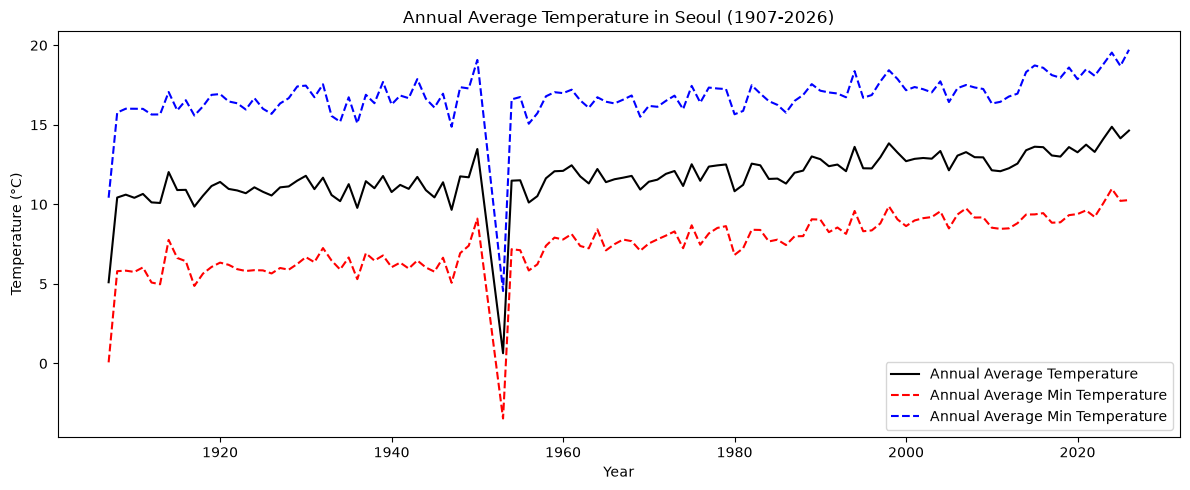

In [11]:
plt.figure(figsize=(12, 5))
plt.plot(annual_temperature["year"], annual_temperature["avg_temp"], 'k-', label="Annual Average Temperature")
plt.plot(annual_temperature["year"], annual_temperature["avg_min_temp"], 'r--', label="Annual Average Min Temperature")
plt.plot(annual_temperature["year"], annual_temperature["avg_max_temp"], 'b--', label="Annual Average Min Temperature")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.title("Annual Average Temperature in Seoul (1907-2026)")
plt.legend(loc=4)
plt.tight_layout()
plt.show()

* 서울시 연평균 평균온도, 최저온도, 최고온도는 상승세에 있음. (선형회귀 분석은 후에 할 예정)
* 1907년과 1950~1953년은 수개월 동안의 결측치로 인해 연평균 기온이 왜곡(1950년은 과다, 1907년 및 1951~1953년은 과소)되어 그래프에 표시되었음. 따라서 이 구간은 데이터 해석 시 제외하거나 유의해야 함.

### 2. Summer and winter temperature

Calculate 'summer' (6월~8월) and 'winter' (12월~2월) average temperatures:

In [4]:
seasonal_temperature = (
    df2[df2["season"].isin(["Summer", "Winter"])]
    .groupby(["year", "season"])["tavg"]
    .mean()
    .reset_index()
)

print(seasonal_temperature.head())

   year  season       tavg
0  1907  Winter  -3.890323
1  1908  Summer  22.872826
2  1908  Winter  -2.751648
3  1909  Summer  23.510870
4  1909  Winter  -3.058889


In [5]:
# reshape the table

seasonal_temperature_pivot = (
    seasonal_temperature
    .pivot(
        index="year",
        columns="season",
        values="tavg"
    ).reset_index()
)

print(seasonal_temperature_pivot.head())

season  year     Summer    Winter
0       1907        NaN -3.890323
1       1908  22.872826 -2.751648
2       1909  23.510870 -3.058889
3       1910  22.463043 -3.427778
4       1911  22.961957 -3.063333


Visualize summer vs. winter graph:

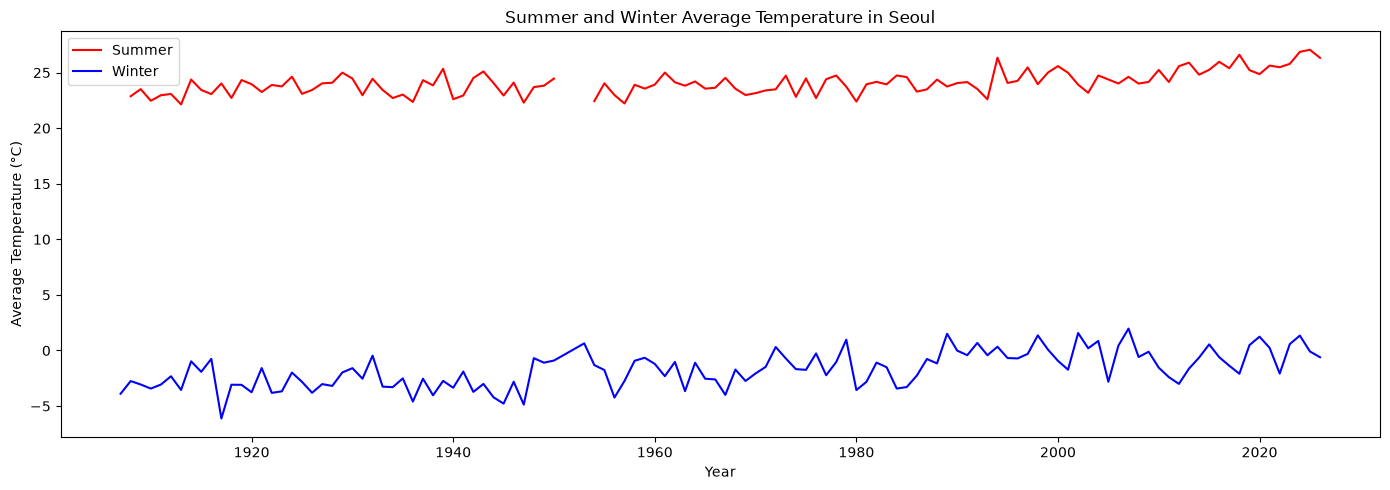

In [7]:
plt.figure(figsize=(14, 5))
plt.plot(seasonal_temperature_pivot["year"],
         seasonal_temperature_pivot["Summer"],
         label="Summer", color="red")
plt.plot(seasonal_temperature_pivot["year"],
         seasonal_temperature_pivot["Winter"],
         label="Winter", color="blue")
plt.xlabel("Year")
plt.ylabel("Average Temperature (°C)")
plt.title("Summer and Winter Average Temperature in Seoul")
plt.legend()
plt.tight_layout()
plt.show()

* 서울시 여름(6월~8월)/겨울(12월~2월) 평균기온은 상승세에 있음.

### 3. Annual 35°C+ days

* 최고 기온(`tmax`)이 35°C 이상인 일수. 'over'라고 했지만 35°C를 포함하기로 함.

In [8]:
annual_over_35 = (df2.groupby("year")["over_35"].sum().reset_index(name="days_over_35"))
print(annual_over_35.head())
print(annual_over_35.tail())

   year  days_over_35
0  1907             0
1  1908             0
2  1909             1
3  1910             0
4  1911             0
     year  days_over_35
113  2022             2
114  2023             1
115  2024             6
116  2025            13
117  2026             7


In [ ]:
annual_over_35.to_csv("../data/processed/annual_over_35.csv", index=False, encoding="utf-8-sig")

Visualize it using a bar graph:

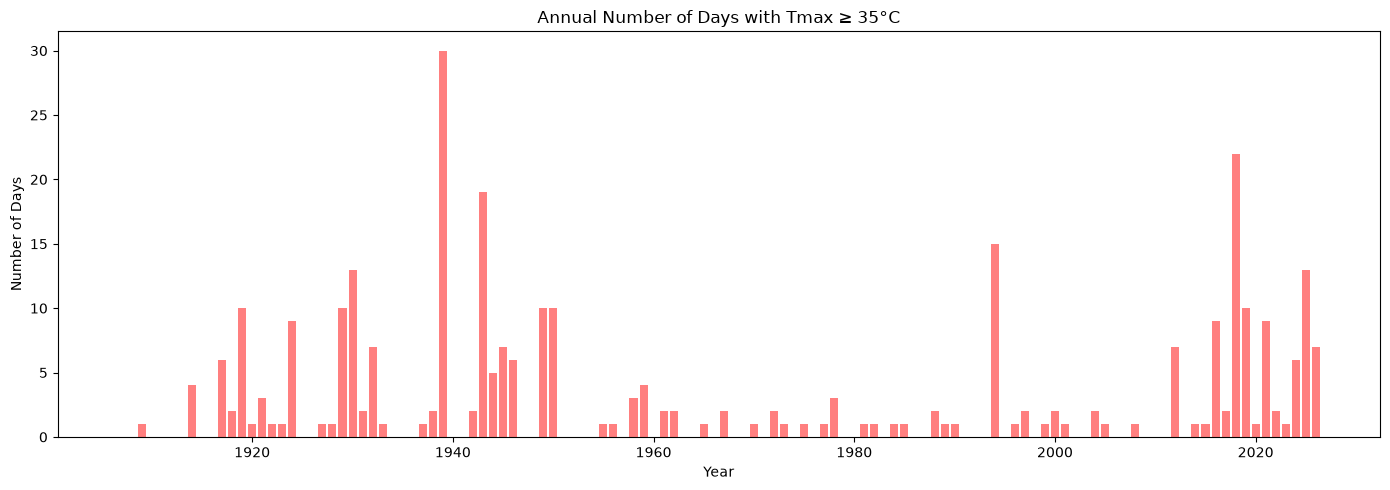

In [14]:
plt.figure(figsize=(14, 5))
plt.bar(annual_over_35["year"], annual_over_35["days_over_35"], color="red", alpha=0.5)
plt.xlabel("Year")
plt.ylabel("Number of Days")
plt.title("Annual Number of Days with Tmax ≥ 35°C")
plt.tight_layout()
plt.show()

* 지난 100여 년간 35°C 이상인 날의 발생 일수는 1939년에 가장 많았으며, 그다음으로 2018년과 1943년이 높은 수준을 기록했다. 특히 1910~1950년 사이에는 35°C 이상인 날이 여러 차례 집중적으로 나타난 반면, 1950~1990년에는 대부분 연간 5일 미만으로 나타났다. 이후 1994년에는 약 15일로 크게 증가했으며, 2012년 이후에는 35°C 이상인 날이 전반적으로 증가하는 경향이 나타난다. 2020년대에는 35°C 이상인 날이 대체로 연간 5~15일 수준으로 나타나고 있다.

### 4. Monthly summer-like / winter-like ratios

This is to answer to the question about seasonal expansion. Instead of simply counting the number of summer-like days, calculated the proportion of days in each month that meet the temperature criterion.

In [11]:
monthly_temperature_characteristics = (
    df2.groupby(["year", "month"])
      .agg(
          summer_like_ratio=("summer_like", "mean"),        # summer_like is 0/1; by doing mean, it gives number btw 0 and 1
          winter_like_ratio=("winter_like", "mean")
      )
      .reset_index()
)

print(monthly_temperature_characteristics.head())

   year  month  summer_like_ratio  winter_like_ratio
0  1907     10                0.0           0.000000
1  1907     11                0.0           0.400000
2  1907     12                0.0           1.000000
3  1908      1                0.0           1.000000
4  1908      2                0.0           0.965517


In [ ]:
monthly_temperature_characteristics.to_csv("../data/processed/monthly_temperature_characteristics.csv", index=False, encoding="utf-8-sig")

본 분석은 한국의 계절이 전통적인 범위(여름 6~8월, 겨울 12~2월)를 넘어 여름과 겨울 중심으로 양극화되는 경향을 확인하고자 한다. 특히 겨울보다는 여름의 확장성에 중점을 두고 분석을 진행할 것이다.
* 여름 확장: May → June → July → August → September
* 겨울 확장: November → December → January → February → March

### 5. Descriptive statistics

In [12]:
print("\n=== Annual Temperature ===")
print(annual_temperature.describe())

print("\n=== Annual 35°C+ Days ===")
print(annual_over_35["days_over_35"].describe())

print("\n=== Summer/Winter Monthly Characteristics ===")
print(monthly_temperature_characteristics[["summer_like_ratio", "winter_like_ratio"]].describe())


=== Annual Temperature ===
              year    avg_temp  avg_min_temp  avg_max_temp
count   118.000000  118.000000    118.000000    118.000000
mean   1966.754237   11.739839      7.453614     16.730080
std      35.025250    1.630691      1.856911      1.582284
min    1907.000000    0.641935     -3.461290      4.551613
25%    1936.250000   10.983425      6.336159     16.257893
50%    1967.500000   11.740137      7.602921     16.784413
75%    1996.750000   12.562329      8.670457     17.359153
max    2026.000000   14.875410     10.975137     19.716017

=== Annual 35°C+ Days ===
count    118.000000
mean       2.669492
std        4.789688
min        0.000000
25%        0.000000
50%        1.000000
75%        2.000000
max       30.000000
Name: days_over_35, dtype: float64

=== Summer/Winter Monthly Characteristics ===
       summer_like_ratio  winter_like_ratio
count        1388.000000        1388.000000
mean            0.298344           0.310943
std             0.404963           0.402